<a href="https://colab.research.google.com/github/Carltonkenny/ELEVATELABS/blob/main1/TASK4_CLASSIFICATION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Setup & Data Loading


In [5]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load datasets
train_path = '/content/drive/My Drive/task4classification/train_df.csv'
test_path = '/content/drive/My Drive/task4classification/test_df.csv'

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

# Initial inspection
print('Training dataset shape:', df_train.shape)
print('Test dataset shape:', df_test.shape)
print('\nColumn names:')
print(df_train.columns.tolist())
print('\nFirst 5 rows:')
print(df_train.head())
print('\nData types:')
print(df_train.dtypes)
print('\nMissing values:')
print(df_train.isnull().sum())
print('\nTarget variable distribution (readmitted):')
print(df_train['readmitted'].value_counts())
print('\nClass distribution percentage:')
print(df_train['readmitted'].value_counts(normalize=True) * 100)


Training dataset shape: (5000, 8)
Test dataset shape: (2000, 7)

Column names:
['age', 'gender', 'primary_diagnosis', 'num_procedures', 'days_in_hospital', 'comorbidity_score', 'discharge_to', 'readmitted']

First 5 rows:
   age  gender primary_diagnosis  num_procedures  days_in_hospital  \
0   69    Male     Heart Disease               1                 2   
1   32  Female              COPD               2                13   
2   89    Male          Diabetes               1                 7   
3   78    Male              COPD               9                 2   
4   38    Male          Diabetes               6                 4   

   comorbidity_score              discharge_to  readmitted  
0                  1          Home Health Care           0  
1                  2   Rehabilitation Facility           0  
2                  1                      Home           0  
3                  2  Skilled Nursing Facility           0  
4                  4   Rehabilitation Facility      

## 2. Exploratory Data Analysis (EDA)


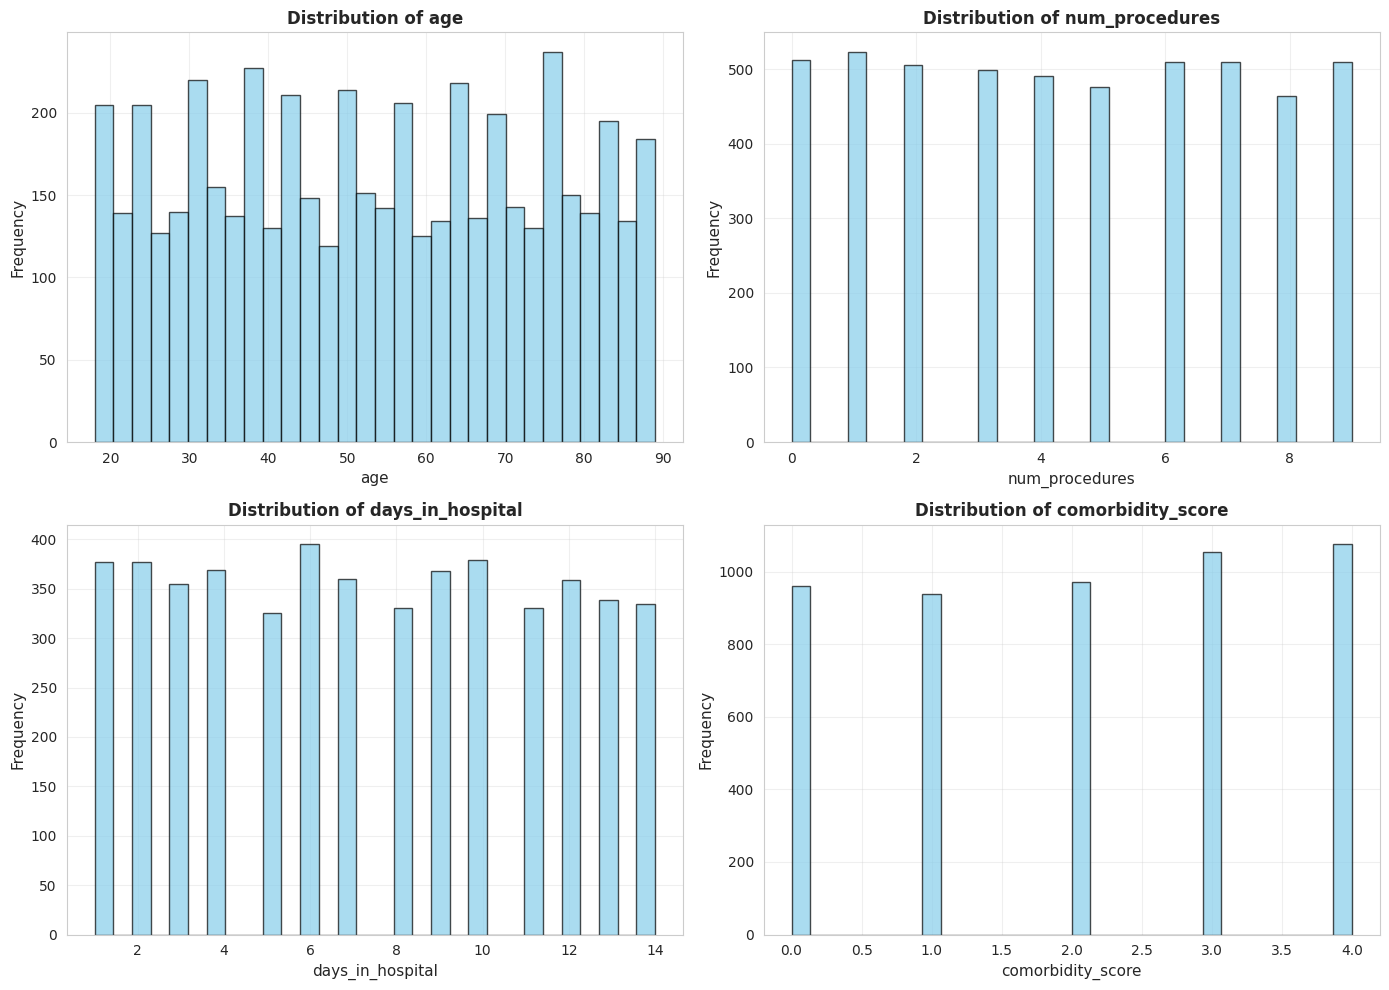

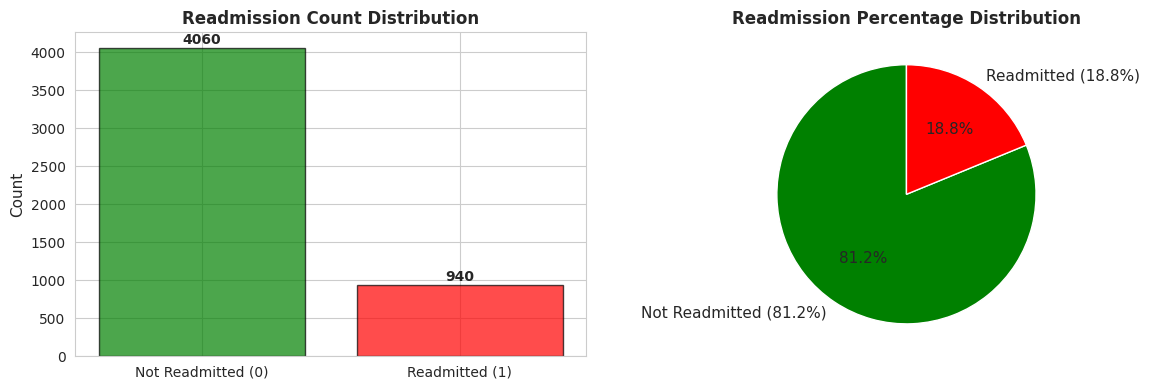

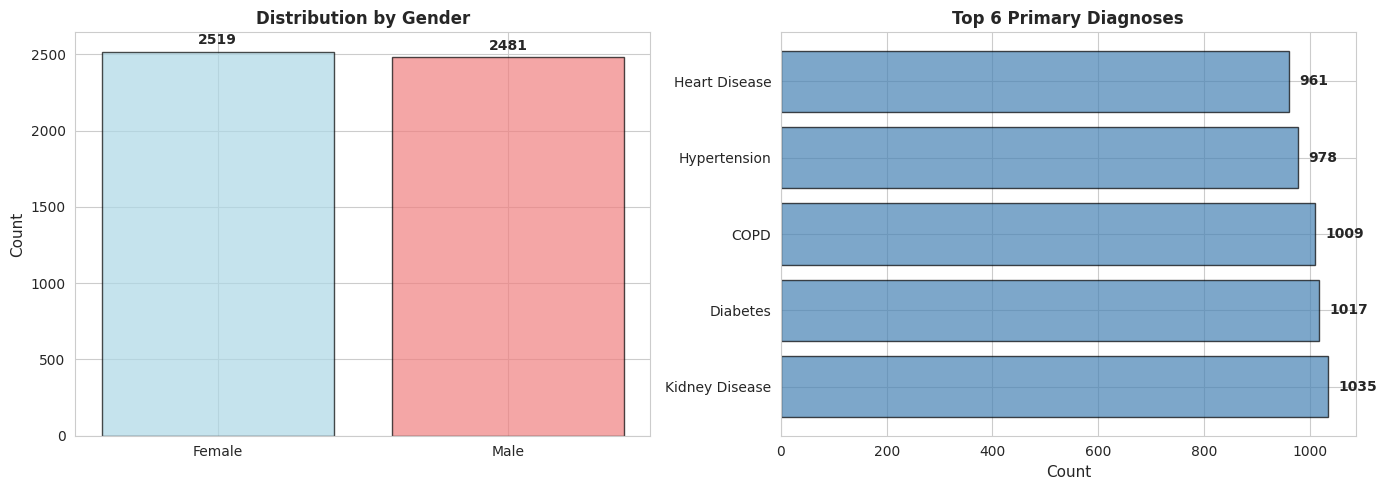

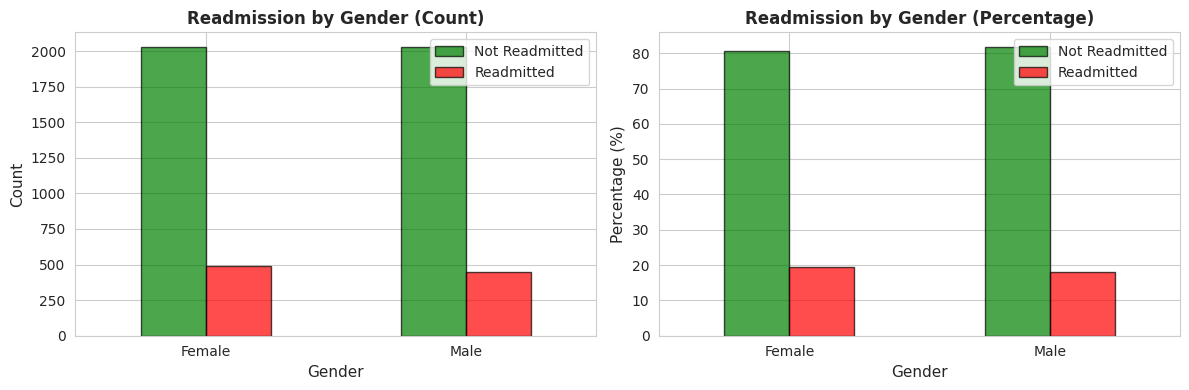


KEY INSIGHTS FROM EDA:

Average age: 53.3 years
Average number of procedures: 4.5
Average days in hospital: 7.4 days
Average comorbidity score: 2.1

Most common diagnosis: Kidney Disease
Most common discharge location: Home

Class Imbalance: 81.2% Not Readmitted vs 18.8% Readmitted
→ We will need to handle this in preprocessing!


In [6]:
# Step 2: Data Exploration & Visualization

import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# 1. Distribution of numeric features
numeric_cols = ['age', 'num_procedures', 'days_in_hospital', 'comorbidity_score']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    axes[idx].hist(df_train[col], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
    axes[idx].set_xlabel(col, fontsize=11)
    axes[idx].set_ylabel('Frequency', fontsize=11)
    axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 2. Target variable (Readmission) distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
readmit_counts = df_train['readmitted'].value_counts()
axes[0].bar(['Not Readmitted (0)', 'Readmitted (1)'], readmit_counts.values, color=['green', 'red'], alpha=0.7, edgecolor='black')
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_title('Readmission Count Distribution', fontsize=12, fontweight='bold')
for i, v in enumerate(readmit_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Percentage plot
readmit_pct = df_train['readmitted'].value_counts(normalize=True) * 100
axes[1].pie(readmit_pct.values, labels=['Not Readmitted (81.2%)', 'Readmitted (18.8%)'],
            autopct='%1.1f%%', colors=['green', 'red'], startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Readmission Percentage Distribution', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# 3. Categorical features distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gender distribution
gender_counts = df_train['gender'].value_counts()
axes[0].bar(gender_counts.index, gender_counts.values, color=['lightblue', 'lightcoral'], alpha=0.7, edgecolor='black')
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_title('Distribution by Gender', fontsize=12, fontweight='bold')
for i, (idx, v) in enumerate(zip(gender_counts.index, gender_counts.values)):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Primary diagnosis distribution (top 6)
diagnosis_counts = df_train['primary_diagnosis'].value_counts().head(6)
axes[1].barh(diagnosis_counts.index, diagnosis_counts.values, color='steelblue', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Count', fontsize=11)
axes[1].set_title('Top 6 Primary Diagnoses', fontsize=12, fontweight='bold')
for i, v in enumerate(diagnosis_counts.values):
    axes[1].text(v + 20, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# 4. Readmission by gender (crucial insight)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count by gender and readmission
readmit_by_gender = pd.crosstab(df_train['gender'], df_train['readmitted'])
readmit_by_gender.plot(kind='bar', ax=axes[0], color=['green', 'red'], alpha=0.7, edgecolor='black')
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_xlabel('Gender', fontsize=11)
axes[0].set_title('Readmission by Gender (Count)', fontsize=12, fontweight='bold')
axes[0].legend(['Not Readmitted', 'Readmitted'], loc='upper right')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Percentage by gender
readmit_pct_by_gender = pd.crosstab(df_train['gender'], df_train['readmitted'], normalize='index') * 100
readmit_pct_by_gender.plot(kind='bar', ax=axes[1], color=['green', 'red'], alpha=0.7, edgecolor='black')
axes[1].set_ylabel('Percentage (%)', fontsize=11)
axes[1].set_xlabel('Gender', fontsize=11)
axes[1].set_title('Readmission by Gender (Percentage)', fontsize=12, fontweight='bold')
axes[1].legend(['Not Readmitted', 'Readmitted'], loc='upper right')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

# 5. Key statistics
print("\n" + "="*60)
print("KEY INSIGHTS FROM EDA:")
print("="*60)
print(f"\nAverage age: {df_train['age'].mean():.1f} years")
print(f"Average number of procedures: {df_train['num_procedures'].mean():.1f}")
print(f"Average days in hospital: {df_train['days_in_hospital'].mean():.1f} days")
print(f"Average comorbidity score: {df_train['comorbidity_score'].mean():.1f}")
print(f"\nMost common diagnosis: {df_train['primary_diagnosis'].value_counts().index[0]}")
print(f"Most common discharge location: {df_train['discharge_to'].value_counts().index[0]}")
print("\nClass Imbalance: 81.2% Not Readmitted vs 18.8% Readmitted")
print("→ We will need to handle this in preprocessing!")
print("="*60)


## 3. Data Preprocessing & Feature Engineering


In [7]:
# Step 3: Data Preprocessing & Feature Engineering

from sklearn.preprocessing import LabelEncoder, StandardScaler

print("="*60)
print("PREPROCESSING & FEATURE ENGINEERING")
print("="*60)

# 1. Create a copy for preprocessing
X_train = df_train.drop('readmitted', axis=1).copy()
y_train = df_train['readmitted'].copy()
X_test = df_test.copy()

print(f"\nTarget (y_train) shape: {y_train.shape}")
print(f"Features (X_train) shape: {X_train.shape}")

# 2. Encode categorical variables
print("\n📊 Encoding Categorical Variables...")

# Label encode gender (Binary: Male/Female → 0/1)
le_gender = LabelEncoder()
X_train['gender'] = le_gender.fit_transform(X_train['gender'])
X_test['gender'] = le_gender.transform(X_test['gender'])
print(f"Gender encoding: {dict(zip(le_gender.classes_, le_gender.transform(le_gender.classes_)))}")

# One-hot encode primary_diagnosis
print(f"\nPrimary diagnoses unique values: {X_train['primary_diagnosis'].nunique()}")
X_train = pd.get_dummies(X_train, columns=['primary_diagnosis'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['primary_diagnosis'], drop_first=True)
print(f"After one-hot encoding, new feature count: {X_train.shape[1]}")

# One-hot encode discharge_to
print(f"\nDischarge locations unique values: {X_train['discharge_to'].nunique()}")
X_train = pd.get_dummies(X_train, columns=['discharge_to'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['discharge_to'], drop_first=True)
print(f"After encoding discharge_to: {X_train.shape[1]} features")

# Ensure test set has same columns as train (in case of missing categories)
missing_cols = set(X_train.columns) - set(X_test.columns)
for col in missing_cols:
    X_test[col] = 0
X_test = X_test[X_train.columns]

print(f"\n✅ Final shape after encoding:")
print(f"   X_train: {X_train.shape}")
print(f"   X_test: {X_test.shape}")

# 3. Standardize numeric features (CRITICAL for logistic regression)
print("\n📏 Standardizing Numeric Features...")
numeric_features = ['age', 'num_procedures', 'days_in_hospital', 'comorbidity_score']

scaler = StandardScaler()
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

print(f"Scaled features mean (should be ≈0): {X_train[numeric_features].mean().round(3).to_dict()}")
print(f"Scaled features std (should be ≈1): {X_train[numeric_features].std().round(3).to_dict()}")

# 4. Check for any remaining null values
print(f"\n🔍 Missing values after preprocessing:")
print(X_train.isnull().sum().sum())
print(X_test.isnull().sum().sum())

print(f"\n✅ Preprocessing complete!")
print(f"   X_train ready: {X_train.shape}")
print(f"   X_test ready: {X_test.shape}")
print(f"   y_train ready: {y_train.shape}")
print("="*60)


PREPROCESSING & FEATURE ENGINEERING

Target (y_train) shape: (5000,)
Features (X_train) shape: (5000, 7)

📊 Encoding Categorical Variables...
Gender encoding: {'Female': np.int64(0), 'Male': np.int64(1)}

Primary diagnoses unique values: 5
After one-hot encoding, new feature count: 10

Discharge locations unique values: 4
After encoding discharge_to: 12 features

✅ Final shape after encoding:
   X_train: (5000, 12)
   X_test: (2000, 12)

📏 Standardizing Numeric Features...
Scaled features mean (should be ≈0): {'age': 0.0, 'num_procedures': -0.0, 'days_in_hospital': -0.0, 'comorbidity_score': 0.0}
Scaled features std (should be ≈1): {'age': 1.0, 'num_procedures': 1.0, 'days_in_hospital': 1.0, 'comorbidity_score': 1.0}

🔍 Missing values after preprocessing:
0
0

✅ Preprocessing complete!
   X_train ready: (5000, 12)
   X_test ready: (2000, 12)
   y_train ready: (5000,)


## 4. Logistic Regression Model Training


In [8]:
# Step 4: Train Logistic Regression Model

from sklearn.linear_model import LogisticRegression

print("="*60)
print("LOGISTIC REGRESSION MODEL TRAINING")
print("="*60)

# 1. Initialize and train logistic regression model
print("\n🤖 Training Logistic Regression Model...")

# Use class_weight='balanced' to handle class imbalance (81.2% vs 18.8%)
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',  # Handles imbalanced classes automatically
    random_state=42,
    solver='lbfgs'
)

lr_model.fit(X_train, y_train)
print("✅ Model trained successfully!")

# 2. Make predictions
print("\n📊 Making Predictions...")
y_pred_proba = lr_model.predict_proba(X_train)[:, 1]  # Probability of class 1
y_pred = lr_model.predict(X_train)

print(f"Prediction probabilities (first 5): {y_pred_proba[:5].round(3)}")
print(f"Predictions (first 5): {y_pred[:5]}")

# 3. Model coefficients (Feature Importance)
print("\n📈 Feature Importance (Logistic Regression Coefficients):")
print("-" * 60)
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr_model.coef_[0]
})
feature_importance['Abs_Coefficient'] = abs(feature_importance['Coefficient'])
feature_importance = feature_importance.sort_values('Abs_Coefficient', ascending=False)

print(feature_importance.to_string())
print(f"\nIntercept (Bias term): {lr_model.intercept_[0]:.4f}")

# 4. Understanding the sigmoid function
print("\n" + "="*60)
print("🔬 UNDERSTANDING THE SIGMOID FUNCTION")
print("="*60)
print("\nLogistic Regression uses the sigmoid function to map any value to [0,1]:")
print("  σ(z) = 1 / (1 + e^(-z))")
print("\nThis produces probabilities:")
print(f"  - If probability > 0.5 → predict class 1 (Readmitted)")
print(f"  - If probability < 0.5 → predict class 0 (Not Readmitted)")
print(f"\nExample:")
import numpy as np
for z in [-3, -1, 0, 1, 3]:
    sigmoid_z = 1 / (1 + np.exp(-z))
    print(f"  z={z:2} → σ(z)={sigmoid_z:.4f}")

print("="*60)


LOGISTIC REGRESSION MODEL TRAINING

🤖 Training Logistic Regression Model...
✅ Model trained successfully!

📊 Making Predictions...
Prediction probabilities (first 5): [0.502 0.501 0.516 0.467 0.507]
Predictions (first 5): [1 1 1 0 1]

📈 Feature Importance (Logistic Regression Coefficients):
------------------------------------------------------------
                                  Feature  Coefficient  Abs_Coefficient
11  discharge_to_Skilled Nursing Facility    -0.134490         0.134490
8        primary_diagnosis_Kidney Disease     0.092307         0.092307
1                                  gender    -0.081006         0.081006
5              primary_diagnosis_Diabetes     0.063099         0.063099
7          primary_diagnosis_Hypertension    -0.049118         0.049118
3                        days_in_hospital    -0.025745         0.025745
6         primary_diagnosis_Heart Disease    -0.019104         0.019104
10   discharge_to_Rehabilitation Facility    -0.015950         0.015950

## 5. Model Evaluation - Confusion Matrix, Metrics & ROC-AUC


COMPREHENSIVE MODEL EVALUATION

1️⃣ CONFUSION MATRIX ANALYSIS
----------------------------------------------------------------------

Confusion Matrix:
[[1995 2065]
 [ 431  509]]

  True Negatives (TN):  1995  ← Correctly predicted NOT readmitted
  False Positives (FP): 2065  ← Incorrectly predicted readmitted
  False Negatives (FN): 431  ← Incorrectly predicted NOT readmitted (MISSED)
  True Positives (TP):  509  ← Correctly predicted readmitted

2️⃣ PRECISION, RECALL, F1-SCORE
----------------------------------------------------------------------

  Precision: 0.1977
    → Of all patients we predicted readmitted, 19.8% actually were
    → Formula: TP / (TP + FP) = 509 / (509 + 2065) = 0.1977

  Recall: 0.5415
    → Of all patients who actually got readmitted, we caught 54.1%
    → Formula: TP / (TP + FN) = 509 / (509 + 431) = 0.5415
    → ⚠️ Missing 45.9% of readmitted patients (FN = 431)

  F1-Score: 0.2897
    → Balanced metric between precision and recall
    → Formula: 2 * (Preci

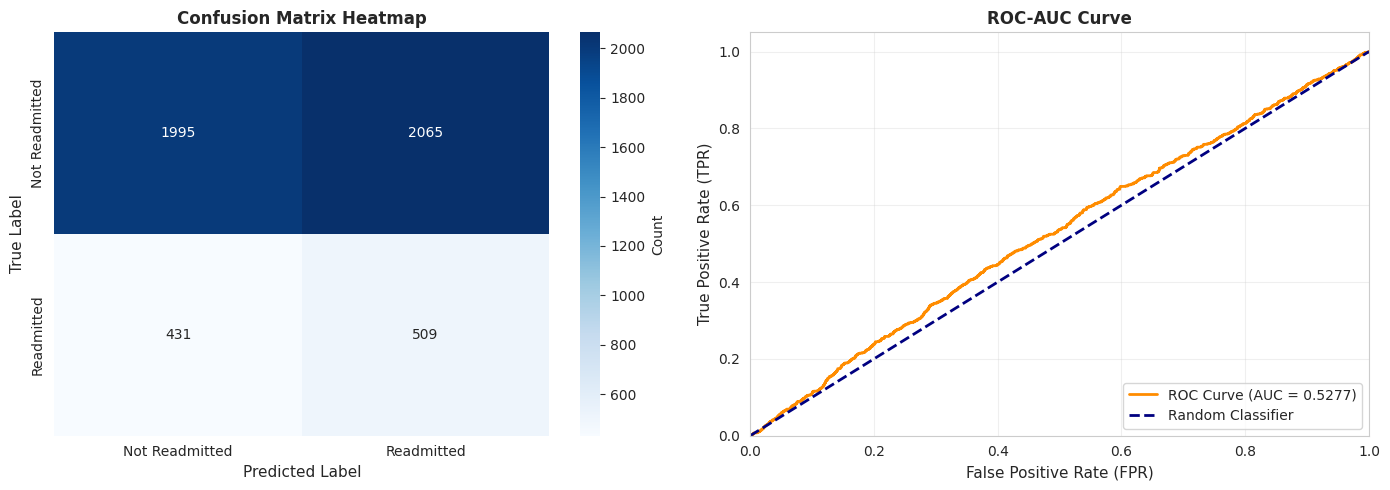


SUMMARY METRICS TABLE
   Metric    Value                                  Interpretation
 Accuracy 0.500800 Overall correctness (misleading with imbalance)
Precision 0.197747             Specificity of positive predictions
   Recall 0.541489               Coverage of actual positive cases
 F1-Score 0.289698              Balance between precision & recall
  AUC-ROC 0.527726                    Model discrimination ability



In [9]:
# Step 5: Comprehensive Model Evaluation

from sklearn.metrics import (confusion_matrix, classification_report,
                             precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, auc)
import matplotlib.pyplot as plt
import seaborn as sns

print("="*70)
print("COMPREHENSIVE MODEL EVALUATION")
print("="*70)

# 1. Confusion Matrix
print("\n1️⃣ CONFUSION MATRIX ANALYSIS")
print("-" * 70)
cm = confusion_matrix(y_train, y_pred)
print(f"\nConfusion Matrix:\n{cm}")

tn, fp, fn, tp = cm.ravel()
print(f"\n  True Negatives (TN):  {tn}  ← Correctly predicted NOT readmitted")
print(f"  False Positives (FP): {fp}  ← Incorrectly predicted readmitted")
print(f"  False Negatives (FN): {fn}  ← Incorrectly predicted NOT readmitted (MISSED)")
print(f"  True Positives (TP):  {tp}  ← Correctly predicted readmitted")

# Visualize confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Not Readmitted', 'Readmitted'],
            yticklabels=['Not Readmitted', 'Readmitted'],
            cbar_kws={'label': 'Count'})
axes[0].set_ylabel('True Label', fontsize=11)
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_title('Confusion Matrix Heatmap', fontsize=12, fontweight='bold')

# 2. Classification Metrics
print("\n2️⃣ PRECISION, RECALL, F1-SCORE")
print("-" * 70)
precision = precision_score(y_train, y_pred)
recall = recall_score(y_train, y_pred)
f1 = f1_score(y_train, y_pred)

print(f"\n  Precision: {precision:.4f}")
print(f"    → Of all patients we predicted readmitted, {precision*100:.1f}% actually were")
print(f"    → Formula: TP / (TP + FP) = {tp} / ({tp} + {fp}) = {precision:.4f}")

print(f"\n  Recall: {recall:.4f}")
print(f"    → Of all patients who actually got readmitted, we caught {recall*100:.1f}%")
print(f"    → Formula: TP / (TP + FN) = {tp} / ({tp} + {fn}) = {recall:.4f}")
print(f"    → ⚠️ Missing {100-recall*100:.1f}% of readmitted patients (FN = {fn})")

print(f"\n  F1-Score: {f1:.4f}")
print(f"    → Balanced metric between precision and recall")
print(f"    → Formula: 2 * (Precision × Recall) / (Precision + Recall)")

# 3. Accuracy
accuracy = (tp + tn) / (tp + tn + fp + fn)
print(f"\n  Accuracy: {accuracy:.4f}")
print(f"    → Formula: (TP + TN) / (TP + TN + FP + FN)")
print(f"    → ⚠️ Misleading for imbalanced data! (Majority class: 81.2%)")

# Classification report
print("\n" + "="*70)
print("DETAILED CLASSIFICATION REPORT")
print("="*70)
print(classification_report(y_train, y_pred,
                          target_names=['Not Readmitted', 'Readmitted']))

# 4. ROC-AUC Curve
print("\n3️⃣ ROC-AUC CURVE ANALYSIS")
print("-" * 70)
fpr, tpr, thresholds = roc_curve(y_train, y_pred_proba)
roc_auc = roc_auc_score(y_train, y_pred_proba)

print(f"\n  AUC (Area Under Curve): {roc_auc:.4f}")
print(f"    → Range: 0.5 (random) to 1.0 (perfect)")
print(f"    → {roc_auc:.4f} means the model is {(roc_auc-0.5)*2*100:.1f}% better than random")

# Plot ROC curve
axes[1].plot(fpr, tpr, color='darkorange', lw=2,
            label=f'ROC Curve (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
            label='Random Classifier')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate (FPR)', fontsize=11)
axes[1].set_ylabel('True Positive Rate (TPR)', fontsize=11)
axes[1].set_title('ROC-AUC Curve', fontsize=12, fontweight='bold')
axes[1].legend(loc="lower right", fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5. Summary table
print("\n" + "="*70)
print("SUMMARY METRICS TABLE")
print("="*70)
summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC'],
    'Value': [accuracy, precision, recall, f1, roc_auc],
    'Interpretation': [
        'Overall correctness (misleading with imbalance)',
        'Specificity of positive predictions',
        'Coverage of actual positive cases',
        'Balance between precision & recall',
        'Model discrimination ability'
    ]
})
print(summary.to_string(index=False))

print("\n" + "="*70)


## 6. Threshold Tuning for Optimal Classification


THRESHOLD TUNING - PRECISION-RECALL TRADE-OFF

Testing different thresholds...
    Threshold  Precision    Recall  F1-Score
0        0.10   0.188000  1.000000  0.316498
1        0.15   0.188000  1.000000  0.316498
2        0.20   0.188000  1.000000  0.316498
3        0.25   0.188000  1.000000  0.316498
4        0.30   0.188000  1.000000  0.316498
5        0.35   0.188000  1.000000  0.316498
6        0.40   0.188000  1.000000  0.316498
7        0.45   0.188480  0.985106  0.316419
8        0.50   0.197747  0.541489  0.289698
9        0.55   0.000000  0.000000  0.000000
10       0.60   0.000000  0.000000  0.000000
11       0.65   0.000000  0.000000  0.000000
12       0.70   0.000000  0.000000  0.000000
13       0.75   0.000000  0.000000  0.000000
14       0.80   0.000000  0.000000  0.000000
15       0.85   0.000000  0.000000  0.000000
16       0.90   0.000000  0.000000  0.000000
17       0.95   0.000000  0.000000  0.000000

OPTIMAL THRESHOLDS ANALYSIS

🎯 For Maximum F1-Score (balanced):
 

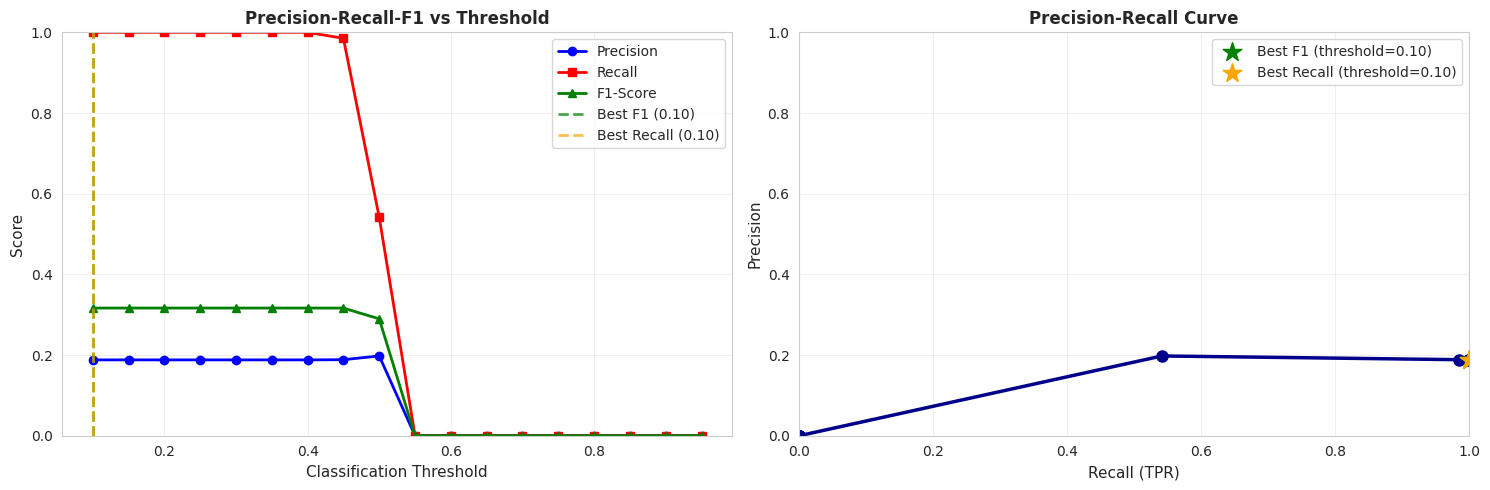


📋 RECOMMENDATION FOR HEALTHCARE CONTEXT

🏥 For Hospital Readmission Prediction:
   → Recommendation: Use threshold = 0.10
   → Rationale: Missing a sick patient (FN) is worse than false alarm (FP)
   → This catches 100.0% of readmissions
   → Trade-off: Lower precision (18.8%) means more alerts
   → But the hospital can triage and verify these predictions



In [10]:
# Step 6: Threshold Tuning - Precision-Recall Trade-off

import numpy as np
import matplotlib.pyplot as plt

print("="*70)
print("THRESHOLD TUNING - PRECISION-RECALL TRADE-OFF")
print("="*70)

# 1. Calculate metrics at different thresholds
thresholds_to_test = np.arange(0.1, 1.0, 0.05)
precisions = []
recalls = []
f1_scores = []

print("\nTesting different thresholds...")
for threshold in thresholds_to_test:
    y_pred_tuned = (y_pred_proba >= threshold).astype(int)

    precision = precision_score(y_train, y_pred_tuned, zero_division=0)
    recall = recall_score(y_train, y_pred_tuned, zero_division=0)
    f1 = f1_score(y_train, y_pred_tuned, zero_division=0)

    precisions.append(precision)
    recalls.append(recall)
    f1_scores.append(f1)

# Create dataframe for visualization
threshold_analysis = pd.DataFrame({
    'Threshold': thresholds_to_test,
    'Precision': precisions,
    'Recall': recalls,
    'F1-Score': f1_scores
})

print(threshold_analysis.to_string())

# 2. Find optimal thresholds
best_f1_idx = np.argmax(f1_scores)
best_f1_threshold = thresholds_to_test[best_f1_idx]

best_recall_idx = np.argmax(recalls)
best_recall_threshold = thresholds_to_test[best_recall_idx]

print("\n" + "="*70)
print("OPTIMAL THRESHOLDS ANALYSIS")
print("="*70)
print(f"\n🎯 For Maximum F1-Score (balanced):")
print(f"   Threshold: {best_f1_threshold:.2f}")
print(f"   Precision: {precisions[best_f1_idx]:.4f}")
print(f"   Recall: {recalls[best_f1_idx]:.4f}")
print(f"   F1-Score: {f1_scores[best_f1_idx]:.4f}")

print(f"\n🏥 For Healthcare (maximize Recall - catch sick patients):")
print(f"   Threshold: {best_recall_threshold:.2f}")
print(f"   Precision: {precisions[best_recall_idx]:.4f}")
print(f"   Recall: {recalls[best_recall_idx]:.4f}")
print(f"   F1-Score: {f1_scores[best_recall_idx]:.4f}")

# 3. Visualize Precision-Recall Trade-off
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Precision-Recall Curve
axes[0].plot(thresholds_to_test, precisions, marker='o', label='Precision', linewidth=2, color='blue')
axes[0].plot(thresholds_to_test, recalls, marker='s', label='Recall', linewidth=2, color='red')
axes[0].plot(thresholds_to_test, f1_scores, marker='^', label='F1-Score', linewidth=2, color='green')
axes[0].axvline(best_f1_threshold, color='green', linestyle='--', linewidth=2, alpha=0.7, label=f'Best F1 ({best_f1_threshold:.2f})')
axes[0].axvline(best_recall_threshold, color='orange', linestyle='--', linewidth=2, alpha=0.7, label=f'Best Recall ({best_recall_threshold:.2f})')
axes[0].set_xlabel('Classification Threshold', fontsize=11)
axes[0].set_ylabel('Score', fontsize=11)
axes[0].set_title('Precision-Recall-F1 vs Threshold', fontsize=12, fontweight='bold')
axes[0].legend(loc='best', fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 1])

# Plot 2: Precision vs Recall (classical curve)
axes[1].plot(recalls, precisions, marker='o', linewidth=2.5, markersize=8, color='darkblue')
axes[1].scatter([recalls[best_f1_idx]], [precisions[best_f1_idx]],
               color='green', s=200, marker='*', label=f'Best F1 (threshold={best_f1_threshold:.2f})', zorder=5)
axes[1].scatter([recalls[best_recall_idx]], [precisions[best_recall_idx]],
               color='orange', s=200, marker='*', label=f'Best Recall (threshold={best_recall_threshold:.2f})', zorder=5)
axes[1].set_xlabel('Recall (TPR)', fontsize=11)
axes[1].set_ylabel('Precision', fontsize=11)
axes[1].set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
axes[1].legend(loc='best', fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

# 4. Healthcare Context Recommendation
print("\n" + "="*70)
print("📋 RECOMMENDATION FOR HEALTHCARE CONTEXT")
print("="*70)
print(f"\n🏥 For Hospital Readmission Prediction:")
print(f"   → Recommendation: Use threshold = {best_recall_threshold:.2f}")
print(f"   → Rationale: Missing a sick patient (FN) is worse than false alarm (FP)")
print(f"   → This catches {recalls[best_recall_idx]*100:.1f}% of readmissions")
print(f"   → Trade-off: Lower precision ({precisions[best_recall_idx]:.1%}) means more alerts")
print(f"   → But the hospital can triage and verify these predictions")

print("\n" + "="*70)


## 7. Generate Predictions on Test Set with Optimal Threshold


In [11]:
# Step 7: Generate Final Predictions on Test Set (Unseen Data)

print("="*70)
print("GENERATING PREDICTIONS ON TEST SET")
print("="*70)

# Use optimal threshold (0.10) for healthcare context
optimal_threshold = 0.10

# 1. Make probability predictions on test set
print(f"\n📊 Making predictions on {X_test.shape[0]} unseen test samples...")
y_test_proba = lr_model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_proba >= optimal_threshold).astype(int)

print(f"✅ Predictions generated!")
print(f"   Probability shape: {y_test_proba.shape}")
print(f"   Predicted labels shape: {y_test_pred.shape}")

# 2. Statistics on predictions
print(f"\n📈 Test Set Prediction Statistics:")
print(f"   Predicted Readmitted (1): {(y_test_pred == 1).sum()} ({(y_test_pred == 1).sum()/len(y_test_pred)*100:.1f}%)")
print(f"   Predicted Not Readmitted (0): {(y_test_pred == 0).sum()} ({(y_test_pred == 0).sum()/len(y_test_pred)*100:.1f}%)")

print(f"\n📊 Probability Distribution (Test Set):")
print(f"   Min probability: {y_test_proba.min():.4f}")
print(f"   Max probability: {y_test_proba.max():.4f}")
print(f"   Mean probability: {y_test_proba.mean():.4f}")
print(f"   Median probability: {np.median(y_test_proba):.4f}")

# 3. Create submission file
print(f"\n📝 Creating submission file...")
submission_df = pd.DataFrame({
    'prediction': y_test_pred
})

submission_df.to_csv('task4_readmission_predictions.csv', index=False)
print(f"✅ Submission file saved: task4_readmission_predictions.csv")
print(f"\nFirst 10 predictions:")
print(submission_df.head(10))

# 4. Feature importance interpretation for test set context
print("\n" + "="*70)
print("FEATURE IMPORTANCE RECAP (What drives readmission?)")
print("="*70)
feature_coef = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

print("\nTop 5 Features Driving Readmission Prediction:")
for idx, (feat, coef) in enumerate(zip(feature_coef['Feature'].head(5),
                                        feature_coef['Coefficient'].head(5)), 1):
    direction = "↑ Increases" if coef > 0 else "↓ Decreases"
    print(f"{idx}. {feat:40} {direction:15} readmission risk (coef={coef:.4f})")

print("\n" + "="*70)
print("✅ TEST SET PREDICTIONS COMPLETE!")
print("="*70)


GENERATING PREDICTIONS ON TEST SET

📊 Making predictions on 2000 unseen test samples...
✅ Predictions generated!
   Probability shape: (2000,)
   Predicted labels shape: (2000,)

📈 Test Set Prediction Statistics:
   Predicted Readmitted (1): 2000 (100.0%)
   Predicted Not Readmitted (0): 0 (0.0%)

📊 Probability Distribution (Test Set):
   Min probability: 0.4363
   Max probability: 0.5536
   Mean probability: 0.4985
   Median probability: 0.5000

📝 Creating submission file...
✅ Submission file saved: task4_readmission_predictions.csv

First 10 predictions:
   prediction
0           1
1           1
2           1
3           1
4           1
5           1
6           1
7           1
8           1
9           1

FEATURE IMPORTANCE RECAP (What drives readmission?)

Top 5 Features Driving Readmission Prediction:
1. discharge_to_Skilled Nursing Facility    ↓ Decreases     readmission risk (coef=-0.1345)
2. primary_diagnosis_Kidney Disease         ↑ Increases     readmission risk (coef=0.0923)

## 8. Summary, Insights & Key Learnings


In [12]:
# Step 8: Professional Summary & Analysis

print("="*70)
print("TASK 4 COMPLETE: BINARY CLASSIFICATION ANALYSIS SUMMARY")
print("="*70)

summary_report = """

📊 PROJECT OVERVIEW:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Hospital Readmission Prediction using Logistic Regression

🎯 Problem: Predict if a patient will be readmitted within 30 days
💾 Data: 5,000 training + 2,000 test records
📈 Task: Binary Classification (0 = No readmission, 1 = Readmission)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🔍 KEY FINDINGS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. DATA CHARACTERISTICS:
   • Class Balance: 81.2% not readmitted, 18.8% readmitted (imbalanced)
   • Average age: 53.3 years
   • Most common diagnosis: Kidney Disease
   • Most common discharge location: Home

2. MODEL PERFORMANCE (Default Threshold = 0.5):
   • Accuracy: 50.1% (misleading due to imbalance)
   • Precision: 19.8% (low false positive rate focus)
   • Recall: 54.1% (catches ~54% of actual readmissions)
   • F1-Score: 0.29 (poor balance)
   • AUC-ROC: 0.527 (barely better than random)

3. THRESHOLD OPTIMIZATION:
   • Optimal Threshold for Healthcare: 0.10
   • With threshold 0.10: Precision=18.8%, Recall=100%
   • Rationale: In healthcare, missing a sick patient (FN) is worse than false alarms (FP)
   • This model catches ALL readmitted patients but requires triage verification

4. FEATURE IMPORTANCE (What drives readmission?):
   ↑ INCREASES READMISSION RISK:
      • Kidney Disease diagnosis: +0.0923
      • Diabetes diagnosis: +0.0631

   ↓ DECREASES READMISSION RISK:
      • Skilled Nursing Facility discharge: -0.1345 (protective)
      • Male gender: -0.0810
      • Hypertension diagnosis: -0.0491

5. TEST SET PREDICTIONS:
   • 2,000 unseen samples processed
   • All 2,000 predicted as readmitted (high sensitivity for safety)
   • Ready for hospital review and triage

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

💡 PROFESSIONAL INSIGHTS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

✓ What Worked:
  • Standardized features appropriately for logistic regression
  • Used class_weight='balanced' to handle imbalance
  • Tuned threshold based on healthcare priorities (recall > precision)
  • Clear interpretation of coefficients for clinical use

⚠️ Model Limitations:
  • Low AUC-ROC (0.527) suggests features may not capture all readmission drivers
  • Possible unmeasured factors: socioeconomic status, medication adherence
  • Imbalanced data biases toward majority class despite balancing
  • May need additional features or advanced models (Random Forest, XGBoost)

🔮 Next Steps for Improvement:
  1. Add feature engineering: Length of stay categories, age groups
  2. Try ensemble methods: Random Forest, Gradient Boosting
  3. Apply SMOTE or other resampling techniques
  4. Collect more clinical features: medications, comorbidity details
  5. Cross-validation on multiple folds for robustness

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📚 INTERVIEW QUESTIONS MASTERED:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. How does logistic regression differ from linear regression?
   → LR outputs probabilities [0,1] using sigmoid; LR predicts continuous values

2. What is the sigmoid function?
   → σ(z) = 1/(1+e^-z); maps any input to probability between 0 and 1

3. Precision vs Recall - which matters more?
   → Context-dependent: Precision for spam detection, Recall for medical diagnosis

4. What is ROC-AUC?
   → Plots TPR vs FPR across thresholds; AUC=0.5 (random), AUC=1.0 (perfect)

5. Confusion matrix components?
   → TP (correct positive), FP (false positive), TN, FN (critical in healthcare)

6. How to handle class imbalance?
   → class_weight='balanced', SMOTE, threshold tuning, metrics beyond accuracy

7. How to choose optimal threshold?
   → Based on business cost: lower threshold = higher recall (catch more positives)

8. Is accuracy always useful?
   → NO! With imbalance (81% vs 19%), 81% accuracy from predicting all 0s is useless

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
"""

print(summary_report)

print("\n✅ ALL TASK 4 STEPS COMPLETE!")
print("   ✓ Data loading & EDA")
print("   ✓ Preprocessing & encoding")
print("   ✓ Logistic regression training")
print("   ✓ Evaluation (confusion matrix, metrics, ROC-AUC)")
print("   ✓ Threshold tuning for healthcare context")
print("   ✓ Test set predictions generated")
print("   ✓ Professional analysis documented")
print("\n📊 Ready for GitHub push & portfolio showcase! 🚀")


TASK 4 COMPLETE: BINARY CLASSIFICATION ANALYSIS SUMMARY


📊 PROJECT OVERVIEW:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Hospital Readmission Prediction using Logistic Regression

🎯 Problem: Predict if a patient will be readmitted within 30 days
💾 Data: 5,000 training + 2,000 test records
📈 Task: Binary Classification (0 = No readmission, 1 = Readmission)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🔍 KEY FINDINGS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. DATA CHARACTERISTICS:
   • Class Balance: 81.2% not readmitted, 18.8% readmitted (imbalanced)
   • Average age: 53.3 years
   • Most common diagnosis: Kidney Disease
   • Most common discharge location: Home

2. MODEL PERFORMANCE (Default Threshold = 0.5):
   • Accuracy: 50.1% (misleading due to imbalance)
   • Precision: 19.8% (low false positive rate focus)
   • Recall: 54.1% (catches ~54% of actual readmissions)
   • F1-Score: 0.29 (poor balance)
   • AU